In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("portfolio_data.csv")

In [4]:
print(df.shape)        
print(df.head())      
print(df.tail())  

(1520, 5)
       Date        AMZN        DPZ         BTC       NFLX
0  5/1/2013  248.229996  51.190983  106.250000  30.415714
1  5/2/2013  252.550003  51.987320   98.099998  30.641428
2  5/3/2013  258.049988  52.446388  112.900002  30.492857
3  5/6/2013  255.720001  53.205257  109.599998  30.098572
4  5/7/2013  257.730011  54.151505  113.199997  29.464285
           Date         AMZN         DPZ          BTC        NFLX
1515   5/8/2019  1917.770020  283.149994  6171.959961  364.369995
1516   5/9/2019  1899.869995  282.160004  6358.290039  362.750000
1517  5/10/2019  1889.979980  278.369995  7191.359863  361.040009
1518  5/13/2019  1822.680054  273.880005  7980.129883  345.260010
1519  5/14/2019  1840.119995  272.859985  8183.830078  345.609985


In [9]:
print(df.dtypes)

Date     object
AMZN    float64
DPZ     float64
BTC     float64
NFLX    float64
dtype: object


In [10]:
print(df.describe())

              AMZN          DPZ           BTC         NFLX
count  1520.000000  1520.000000   1520.000000  1520.000000
mean    821.541810   146.771695   2421.465669   147.668273
std     518.442653    72.192287   3310.894199   107.641486
min     248.229996    51.190983     69.660004    29.464285
25%     364.360001    84.993593    340.904999    62.851071
50%     686.459992   127.168053    625.304993   104.000000
75%    1121.287536   202.454994   3874.912415   192.207496
max    2039.510010   298.635986  18972.320310   418.970001


In [11]:
print(df.isnull().sum())

Date    0
AMZN    0
DPZ     0
BTC     0
NFLX    0
dtype: int64


In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

print(df.dtypes)
print(df.head())

AMZN    float64
DPZ     float64
BTC     float64
NFLX    float64
dtype: object
                  AMZN        DPZ         BTC       NFLX
Date                                                    
2013-05-01  248.229996  51.190983  106.250000  30.415714
2013-05-02  252.550003  51.987320   98.099998  30.641428
2013-05-03  258.049988  52.446388  112.900002  30.492857
2013-05-06  255.720001  53.205257  109.599998  30.098572
2013-05-07  257.730011  54.151505  113.199997  29.464285


In [13]:
print(df.duplicated().sum())
print(df[df.duplicated()])

0
Empty DataFrame
Columns: [AMZN, DPZ, BTC, NFLX]
Index: []


In [14]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} : {len(outliers)} outliers (bornes [{lower:.2f}, {upper:.2f}])")


AMZN : 0 outliers (bornes [-771.03, 2256.68])
DPZ : 0 outliers (bornes [-91.20, 378.65])
BTC : 71 outliers (bornes [-4960.11, 9175.92])
NFLX : 21 outliers (bornes [-131.18, 386.24])


In [15]:
for col in ["BTC", "NFLX"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col} - outliers :")
    print(outliers[[col]])


BTC - outliers :
                     BTC
Date                    
2017-11-27   9733.200195
2017-11-28   9906.040039
2017-11-29   9837.860352
2017-11-30   9946.759766
2017-12-01  10861.469730
...                  ...
2018-05-02   9745.040039
2018-05-03   9699.610352
2018-05-04   9845.900391
2018-05-07   9196.129883
2018-05-08   9321.160156

[71 rows x 1 columns]

NFLX - outliers :
                  NFLX
Date                  
2018-06-14  392.869995
2018-06-15  391.980011
2018-06-18  390.399994
2018-06-19  404.980011
2018-06-20  416.760010
2018-06-21  415.440002
2018-06-22  411.089996
2018-06-26  399.390015
2018-06-27  390.390015
2018-06-28  395.420013
2018-06-29  391.429993
2018-07-02  398.179993
2018-07-03  390.519989
2018-07-05  398.390015
2018-07-06  408.250000
2018-07-09  418.970001
2018-07-10  415.630005
2018-07-11  418.649994
2018-07-12  413.500000
2018-07-13  395.799988
2018-07-16  400.480011


In [18]:
outliers_info = {}

for col in ["BTC", "NFLX"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_info[col] = {
        "nb_outliers": len(df[(df[col] < lower) | (df[col] > upper)]),
        "borne_basse": round(lower, 2),
        "borne_haute": round(upper, 2),
        "decision": "conservés (tendance marché réelle)"
    }

import json
print(json.dumps(outliers_info, indent=4, default=float))

{
    "BTC": {
        "nb_outliers": 71,
        "borne_basse": -4960.11,
        "borne_haute": 9175.92,
        "decision": "conserv\u00e9s (tendance march\u00e9 r\u00e9elle)"
    },
    "NFLX": {
        "nb_outliers": 21,
        "borne_basse": -131.18,
        "borne_haute": 386.24,
        "decision": "conserv\u00e9s (tendance march\u00e9 r\u00e9elle)"
    }
}


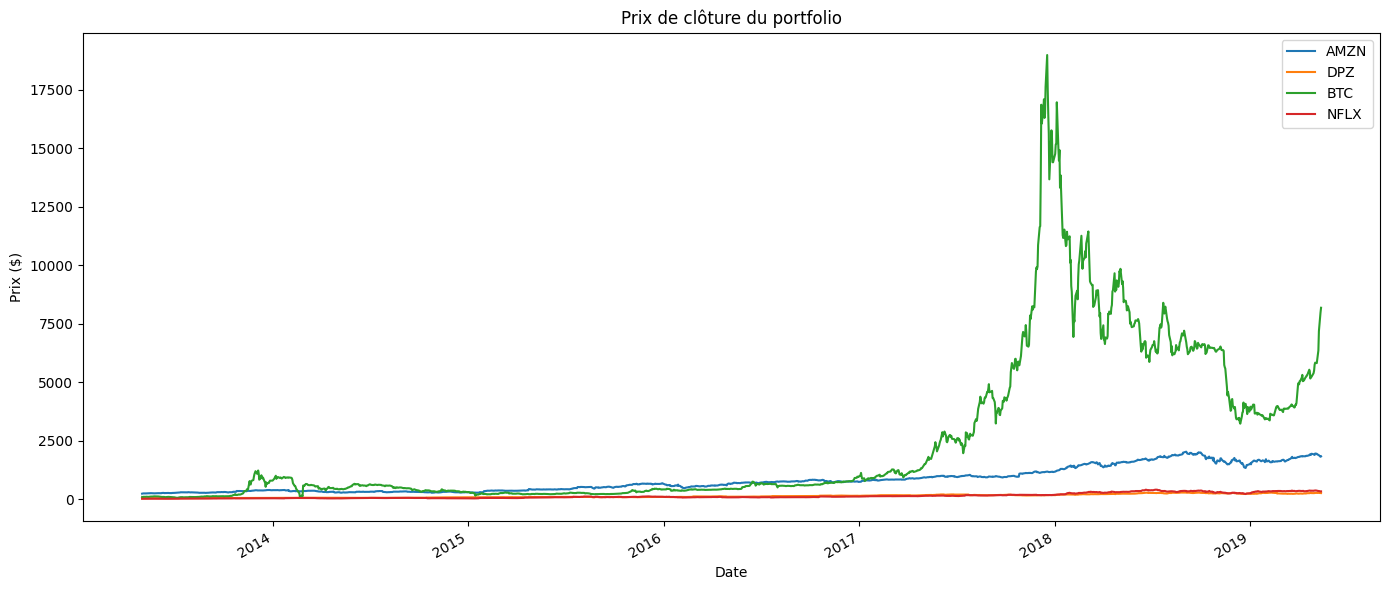

In [20]:
import matplotlib.pyplot as plt

df.plot(figsize=(14, 6), title="Prix de clôture du portfolio")
plt.ylabel("Prix ($)")
plt.xlabel("Date")
plt.legend(["AMZN", "DPZ", "BTC", "NFLX"])
plt.tight_layout()
plt.show()

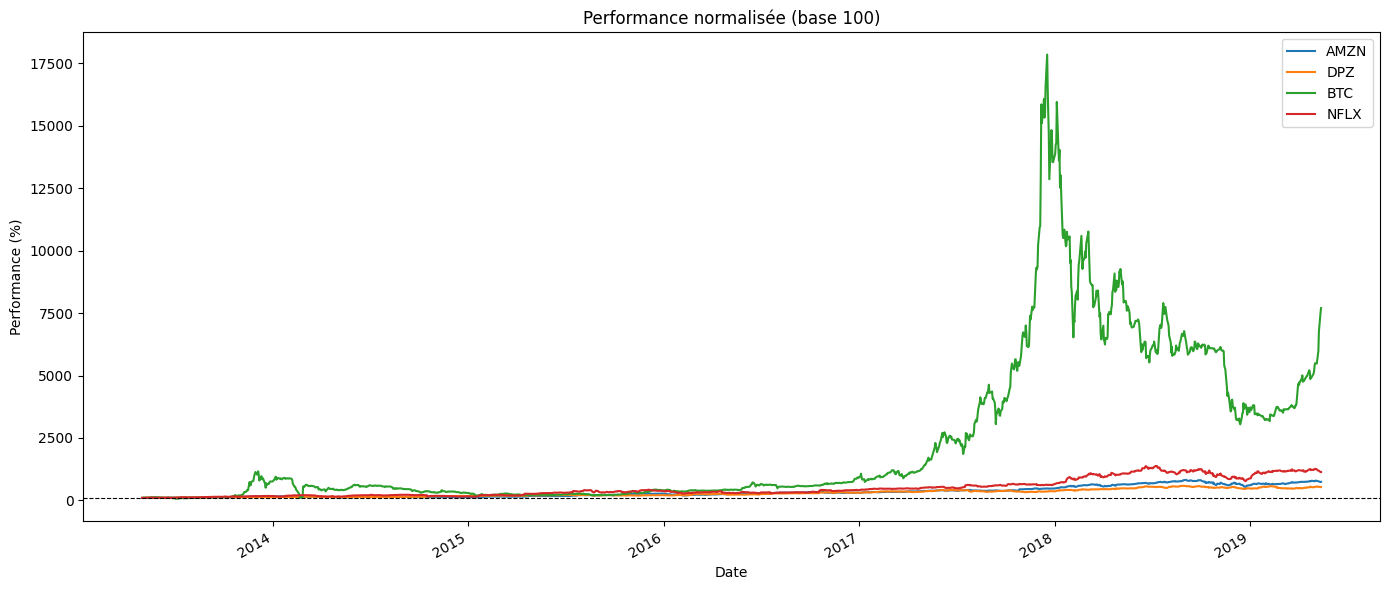

In [22]:
df_normalized = (df / df.iloc[0]) * 100

df_normalized.plot(figsize=(14, 6), title="Performance normalisée (base 100)")
plt.ylabel("Performance (%)")
plt.xlabel("Date")
plt.axhline(y=100, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

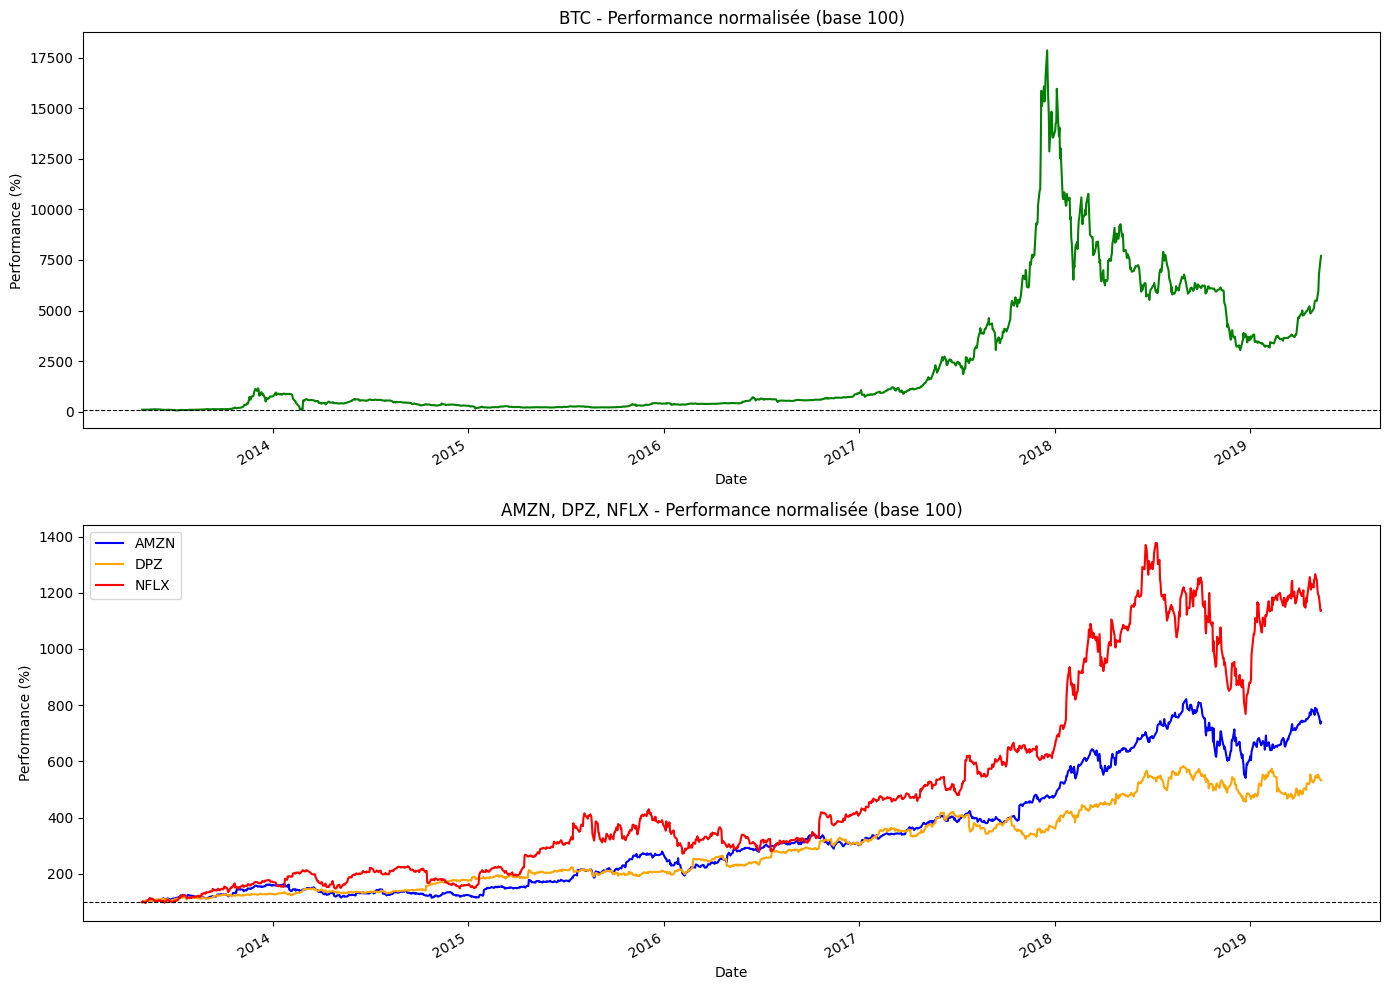

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_normalized["BTC"].plot(ax=ax1, color="green", title="BTC - Performance normalisée (base 100)")
ax1.axhline(y=100, color="black", linestyle="--", linewidth=0.8)
ax1.set_ylabel("Performance (%)")

df_normalized["AMZN"].plot(ax=ax2, color="blue", label="AMZN")
df_normalized["DPZ"].plot(ax=ax2, color="orange", label="DPZ")
df_normalized["NFLX"].plot(ax=ax2, color="red", label="NFLX")  # 👈 rouge ici
ax2.set_title("AMZN, DPZ, NFLX - Performance normalisée (base 100)")
ax2.axhline(y=100, color="black", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Performance (%)")
ax2.set_xlabel("Date")
ax2.legend()

plt.tight_layout()
plt.show()

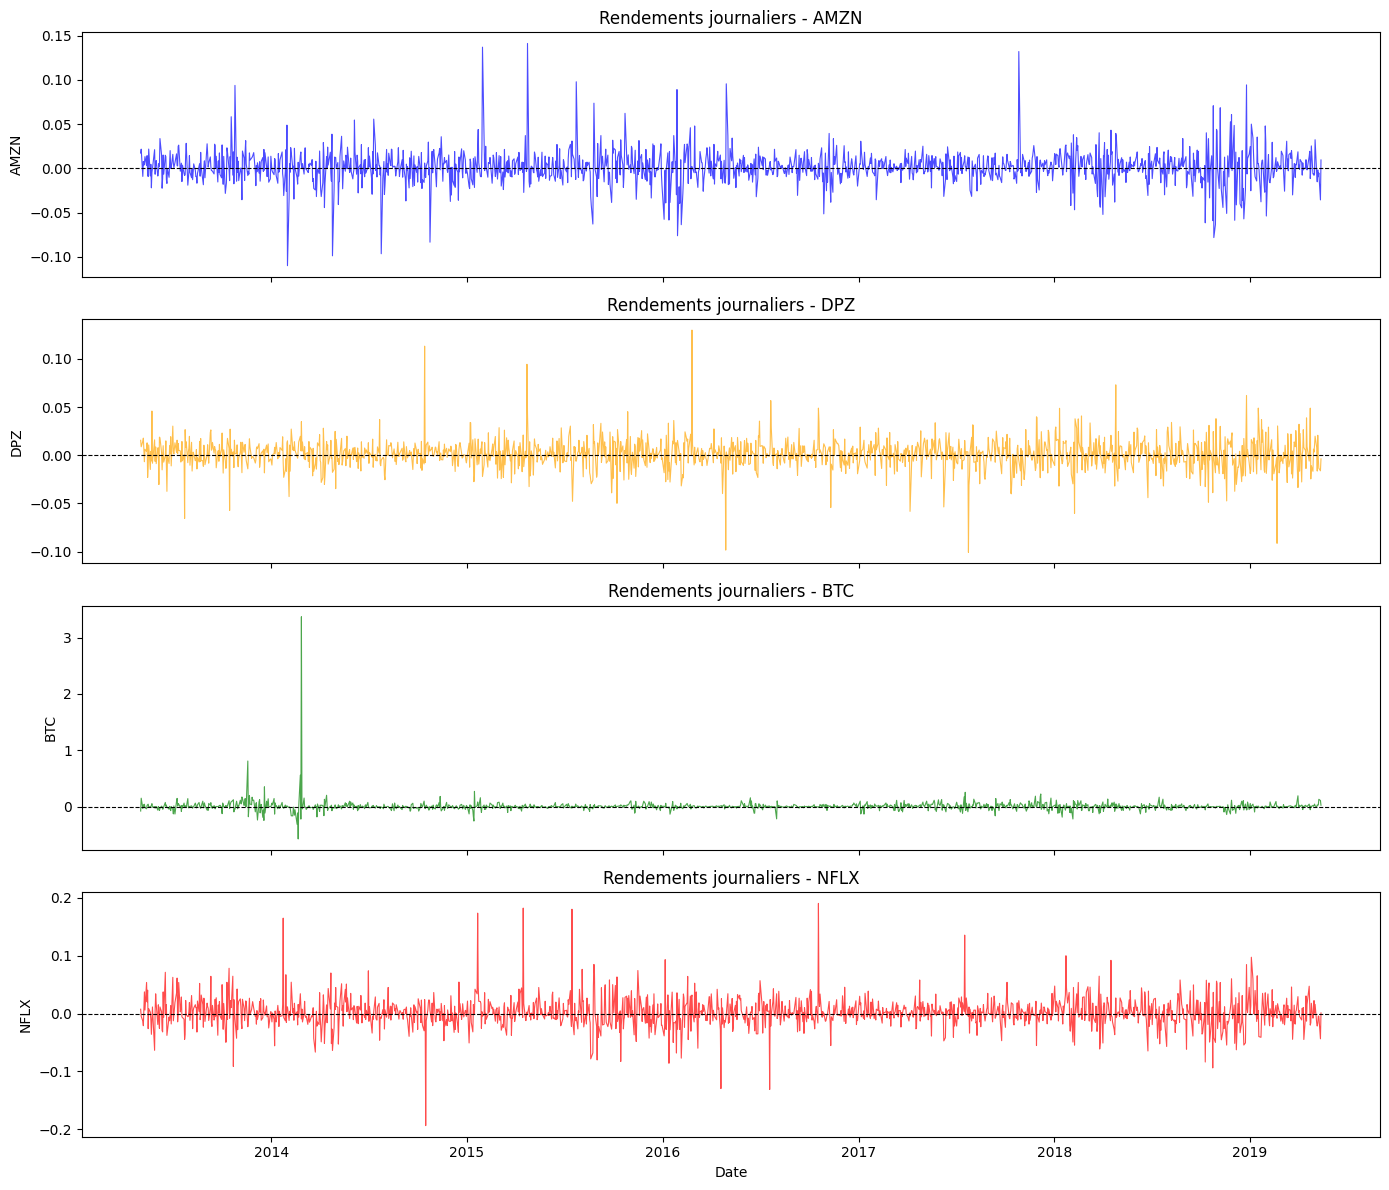

In [25]:
df_returns = df.pct_change().dropna()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

colors = {"AMZN": "blue", "DPZ": "orange", "BTC": "green", "NFLX": "red"}

for ax, col in zip(axes, df_returns.columns):
    ax.plot(df_returns.index, df_returns[col], color=colors[col], alpha=0.7, linewidth=0.8)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_ylabel(col)
    ax.set_title(f"Rendements journaliers - {col}")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

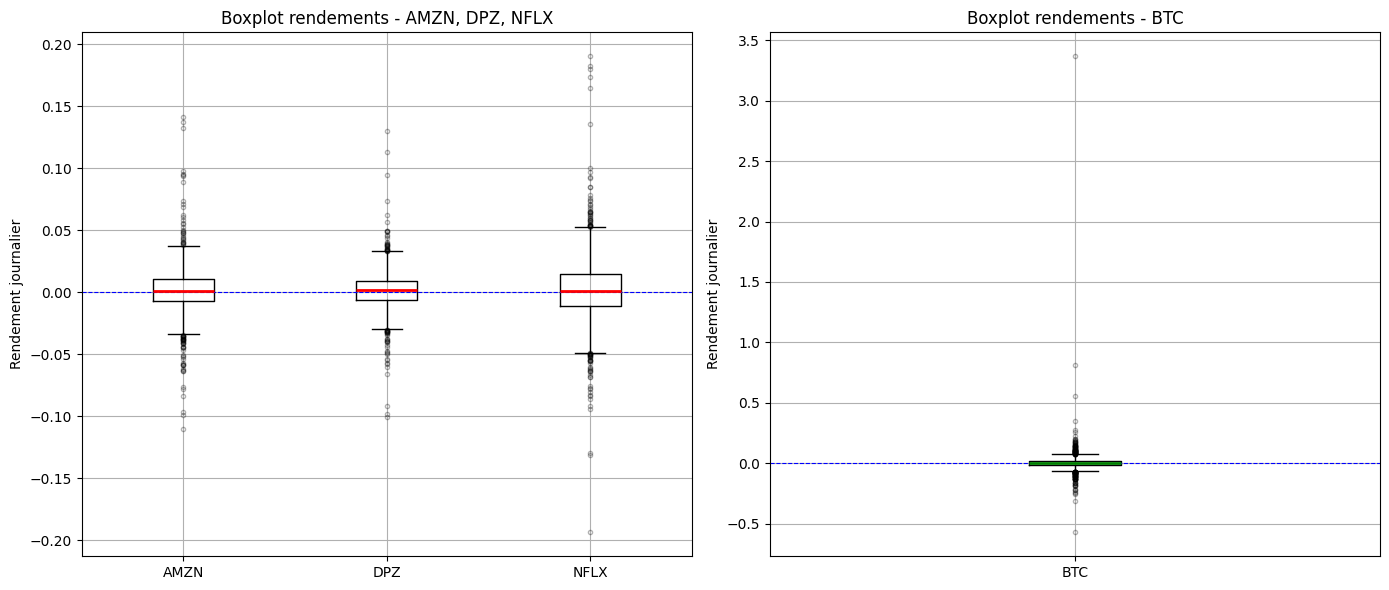

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

df_returns[["AMZN", "DPZ", "NFLX"]].boxplot(
    ax=ax1,
    boxprops=dict(color="black"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markersize=3, alpha=0.3)
)
ax1.set_title("Boxplot rendements - AMZN, DPZ, NFLX")
ax1.set_ylabel("Rendement journalier")
ax1.axhline(y=0, color="blue", linestyle="--", linewidth=0.8)

df_returns[["BTC"]].boxplot(
    ax=ax2,
    boxprops=dict(color="black"),
    medianprops=dict(color="green", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markersize=3, alpha=0.3)
)
ax2.set_title("Boxplot rendements - BTC")
ax2.set_ylabel("Rendement journalier")
ax2.axhline(y=0, color="blue", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

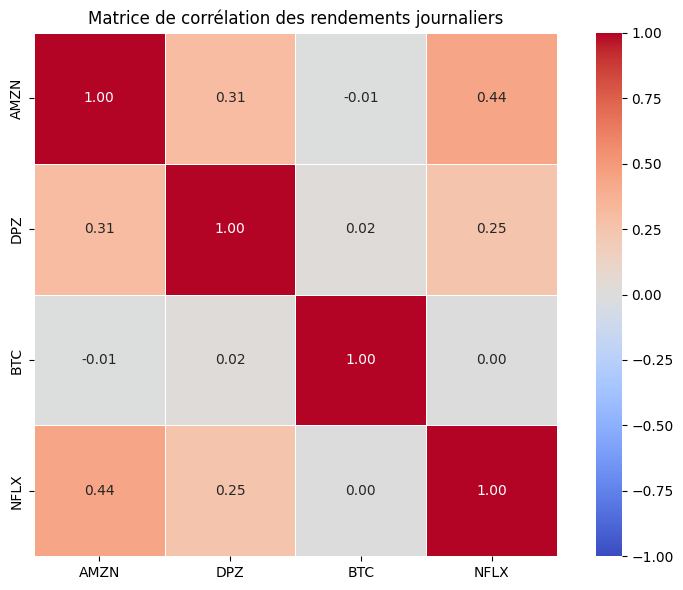

In [28]:
import seaborn as sns

correlation_matrix = df_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Matrice de corrélation des rendements journaliers")
plt.tight_layout()
plt.show()